In [42]:
# Imports
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection  import train_test_split
import ml_pokedex as mlpo
importlib.reload(mlpo)

<module 'ml_pokedex' from 'c:\\Users\\Dell\\Documents\\Códigos\\PoupaTempos\\ML-Pokedex\\ml_pokedex.py'>

In [ ]:
# Carregar dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [ ]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

In [ ]:
df_clean, report_data = mlpo.quality_processor(df, df.columns, num_strategy='knn', cat_strategy='most_frequent', encoding='label', knn_neighbors=5)
report_data

,Coluna,Imputação,Encoder,Nulls (Antes),Nulls (Depois),Ref Média (Antes),Ref Média (Depois)
0,sepal length (cm),knn,N/A,0,0,5.843333,5.843333
1,sepal width (cm),knn,N/A,0,0,3.057333,3.057333
2,petal length (cm),knn,N/A,0,0,3.758000,3.758000
3,petal width (cm),knn,N/A,0,0,1.199333,1.199333


In [40]:
# Exemplo: aplicar na variável "sepal length (cm)"
df_results, best_transforms = mlpo.apply_scaling(df, df.columns)
df_results

c:\Users\Dell\Documents\Códigos\PoupaTempos\ML-Pokedex\.venv3\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\Dell\Documents\Códigos\PoupaTempos\ML-Pokedex\.venv3\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\Dell\Documents\Códigos\PoupaTempos\ML-Pokedex\.venv3\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\Dell\Documents\Códigos\PoupaTempos\ML-Pokedex\.venv3\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(


,coluna,transformacao,p_value,is_normal
0,sepal length (cm),Original,5.682425e-02,True
1,sepal length (cm),StandardScaler,5.682425e-02,True
2,sepal length (cm),MinMaxScaler,5.682425e-02,True
3,sepal length (cm),RobustScaler,5.682425e-02,True
4,sepal length (cm),MaxAbsScaler,5.682425e-02,True
5,sepal length (cm),QuantileTransformer,1.818261e-05,False
6,sepal length (cm),PowerTransformer,1.624851e-02,False
7,sepal width (cm),Original,2.097338e-01,True
8,sepal width (cm),StandardScaler,2.097338e-01,True
9,sepal width (cm),MinMaxScaler,2.097338e-01,True


In [27]:
best_transforms

,coluna,transformacao,p_value,is_normal
13,sepal width (cm),PowerTransformer,9.232471e-01,True
0,sepal length (cm),Original,5.682425e-02,True
19,petal length (cm),QuantileTransformer,1.861278e-05,False
26,petal width (cm),QuantileTransformer,6.911604e-08,False


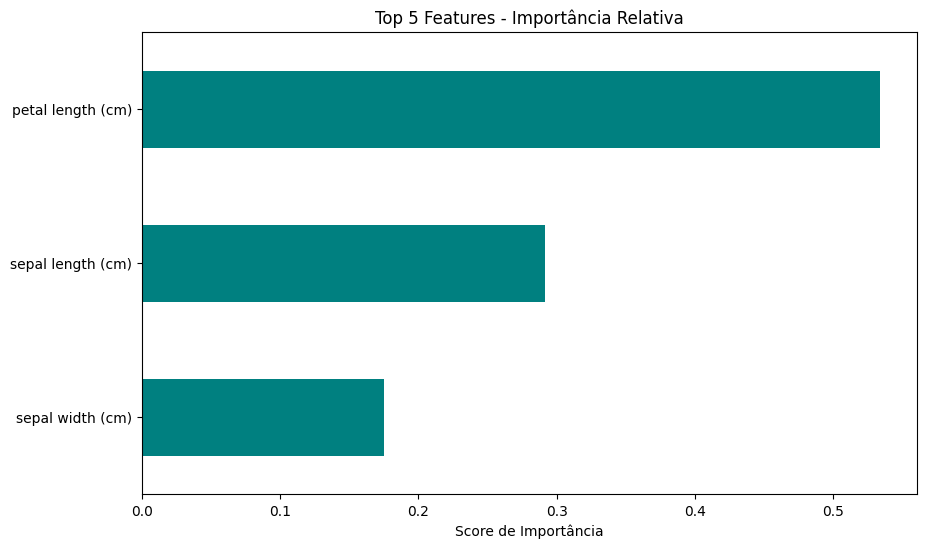

petal length (cm)    0.533493
sepal length (cm)    0.291427
sepal width (cm)     0.175080
dtype: float64

In [46]:
# Carregar dataset Iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Exemplo de uso:
X_top, resumo, ranking = mlpo.feature_selector(X_train, y_train, k=5)
ranking